# F1 — Championship Storylines (1950–2024)

Three "narrative" questions about how titles were *won and lost* — not aggregate counts, but specific storylines that show up in the data.
This notebook covers **Section 3** of `QuestionsF1.txt`.

## Questions covered
| # | Question |
|---|---|
| 3.1 | Drivers who led the standings wire-to-wire (1st place after every Sunday race of the season) |
| 3.2 | Drivers who won the last 3 races of a season but didn't become champion |
| 3.3 | Seasons where the champion did NOT finish the last race of the season |

The Constructors' Championship started in 1958 — but the **Drivers'** Championship has existed since 1950, so all three questions cover 1950 onward.


## Setup — imports and data loading


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from f1_utils import (
    show_and_save, eras_df, year_to_era, apply_default_style,
)
apply_default_style()

sns.set_theme(style='whitegrid')

drivers     = pd.read_csv('excel/drivers.csv')
results     = pd.read_csv('excel/results.csv')
races       = pd.read_csv('excel/races.csv')
constructors= pd.read_csv('excel/constructors.csv')
standings   = pd.read_csv('excel/driver_standings.csv')

# Compact display name used everywhere — 'Hamilton L.', 'Verstappen M.'
drivers['driver'] = drivers['surname'] + ' ' + drivers['forename'].str[0] + '.'

print('drivers     :', drivers.shape)
print('results     :', results.shape)
print('races       :', races.shape)
print('constructors:', constructors.shape)
print('standings   :', standings.shape)


os.makedirs('charts', exist_ok=True)


def show_and_save(filename, dpi=150):
    """Save current figure to charts/ and display inline."""
    plt.savefig(f'charts/{filename}', dpi=dpi, bbox_inches='tight')
    plt.show()


drivers     : (861, 10)
results     : (26759, 18)
races       : (1125, 18)
constructors: (212, 5)
standings   : (34863, 7)


## Data cleanup — Indianapolis 500 (1950–1960)

Same cleanup as the other notebooks: strip Indy 500 races so per-driver / per-season statistics aren't polluted by drivers who never raced anywhere else.


In [ ]:
indy_race_ids = races.loc[
    races['name'].str.contains('Indianapolis', case=False, na=False),
    'raceId'
]
n_before = len(results)

results   = results  [~results  ['raceId'].isin(indy_race_ids)].copy()
races     = races    [~races    ['raceId'].isin(indy_race_ids)].copy()
standings = standings[~standings['raceId'].isin(indy_race_ids)].copy()

print(f'Indy 500 races removed   : {len(indy_race_ids)}')
print(f'Result rows dropped      : {n_before - len(results):,}')
print(f'Clean dataset:')
print(f'  races    : {len(races):,}')
print(f'  results  : {len(results):,}')
print(f'  standings: {len(standings):,}')


Indy 500 races removed   : 11
Result rows dropped      : 405
Clean dataset:
  races    : 1,114
  results  : 26,354
  standings: 34,194


## Shared helpers — colors, season-end utilities

`DECADE_COLORS` palette is the same as the other notebooks (so a 1990s driver is teal everywhere). The `last_race_per_year` and `final_standings` frames are reused by every question below — building them once at the top keeps the per-question code short.


In [ ]:
DECADE_COLORS = {
    1950: '#8B2635',  # burgundy
    1960: '#D2691E',  # chocolate orange
    1970: '#DAA520',  # goldenrod
    1980: '#2E8B57',  # sea green
    1990: '#0E7C7B',  # teal
    2000: '#1F4E79',  # navy blue
    2010: '#5B2A86',  # royal purple
    2020: '#3A3A3A',  # dark gray
}

# Standings table joined with race year + round (= 'after which race?')
standings_full = (
    standings
    .merge(races[['raceId', 'year', 'round', 'date']], on='raceId')
)

# Last race of each season — needed for the year-end snapshot
last_race_per_year = (
    races.assign(date=lambda d: pd.to_datetime(d['date']))
    .sort_values('date')
    .groupby('year').last()
    .reset_index()[['year', 'raceId', 'round']]
    .rename(columns={'raceId': 'final_raceId', 'round': 'final_round'})
)

# Final standings of each season (position 1 = champion, etc.)
final_standings = (
    standings_full
    .merge(last_race_per_year[['year', 'final_raceId']], on='year')
    .query('raceId == final_raceId')
    [['year', 'driverId', 'position', 'points', 'wins']]
    .rename(columns={'position': 'champ_position',
                     'points':   'champ_points',
                     'wins':     'champ_wins'})
)

# Just the champion (position == 1) per year — used by 3.3
champions = (
    final_standings.query('champ_position == 1')
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .sort_values('year')
)

print(f'Seasons in dataset : {standings_full["year"].nunique()}')
print(f'Champions on record: {len(champions)} ({champions["year"].min()}–{champions["year"].max()})')


Seasons in dataset : 75
Champions on record: 75 (1950–2024)


---
### Chart 3.1 — Drivers who led the standings wire-to-wire

A driver led **wire-to-wire** if they were the championship leader (`position == 1` in `driver_standings`) **after every single Sunday race of that season**. Before round 1 everyone has 0 points, so the check starts from round 1 and continues through the final round.

Two equivalent ways to state the rule:
1. For every (year, round), the driver at position 1 is the same as in round 1.
2. Across all rounds of the year, the set of unique drivers ever seen at position 1 has size 1.

> ⚠️ **Caveat — the standings table is retroactively corrected.** `driver_standings` reflects the **final, post-penalty** standings, not what was on TV that Sunday evening. For example, Schumacher 1994 looks wire-to-wire here even though Hill briefly led the championship before the FIA disqualified Schumacher from Spa. If you wanted the "as-broadcast" view you'd have to recompute the standings from raw race results, undoing later penalties — out of scope for this notebook.

**Output:**
- A bar chart showing **every driver** with at least one wire-to-wire season, ranked by season count.
- A table listing every wire-to-wire driver-year, with team and final-round margin.


Total wire-to-wire driver-seasons: 19

 year        driver          team  champ_points  runner_up_points  margin
 1953     Ascari A.       Ferrari          34.5             28.00    6.50
 1954     Fangio J.      Mercedes          42.0             25.14   16.86
 1957     Fangio J.      Maserati          40.0             25.00   15.00
 1959    Brabham J. Cooper-Climax          31.0             27.00    4.00
 1962       Hill G.           BRM          42.0             30.00   12.00
 1969    Stewart J.    Matra-Ford          63.0             37.00   26.00
 1991      Senna A.       McLaren          96.0             72.00   24.00
 1992    Mansell N.      Williams         108.0             56.00   52.00
 1994 Schumacher M.      Benetton          92.0             91.00    1.00
 1996       Hill D.      Williams          97.0             78.00   19.00
 1998   Häkkinen M.       McLaren         100.0             86.00   14.00
 2001 Schumacher M.       Ferrari         123.0             65.00   58.00

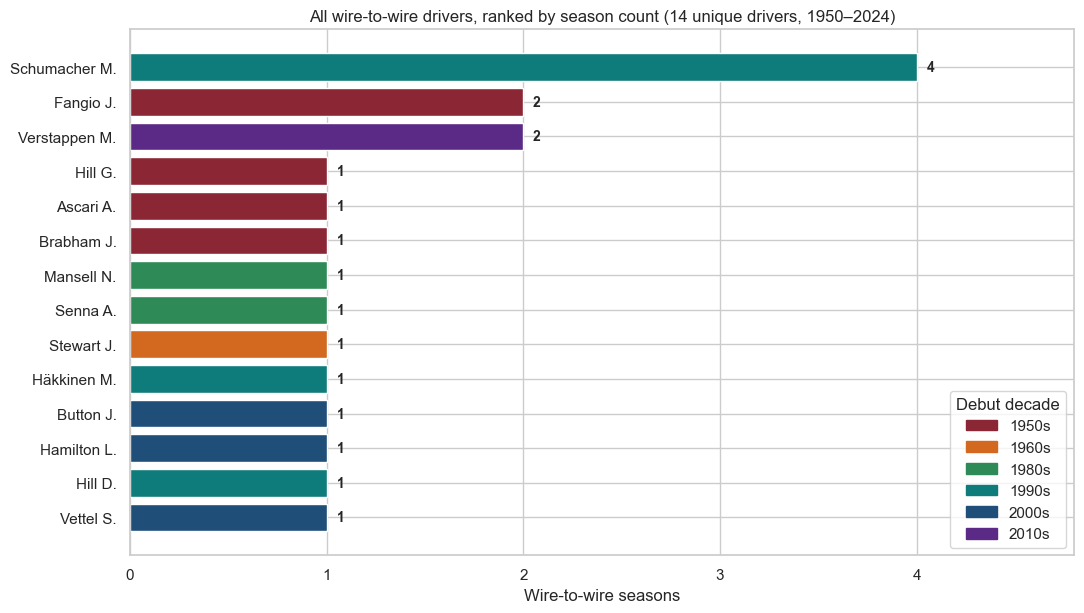

In [ ]:
# Step 1 — leader after every (year, round)
leaders_per_round = (
    standings_full[standings_full['position'] == 1]
    [['year', 'round', 'driverId']]
    .drop_duplicates()
)

# Step 2 — for each year, did the SAME driver lead after every round?
def all_same(g):
    return g['driverId'].nunique() == 1

w2w_years = (
    leaders_per_round.groupby('year').filter(all_same)
    .groupby('year')['driverId'].first().reset_index()
)

# Step 3 — enrich each w2w year with team + margin context
final_w_team = (
    standings_full[standings_full['position'] == 1]
    .merge(last_race_per_year[['year', 'final_raceId']], on='year')
    .query('raceId == final_raceId')
    [['year', 'driverId', 'points']]
    .rename(columns={'points': 'champ_points'})
)

# Runner-up final points (for margin)
runner_up_pts = (
    standings_full[standings_full['position'] == 2]
    .merge(last_race_per_year[['year', 'final_raceId']], on='year')
    .query('raceId == final_raceId')
    [['year', 'points']]
    .rename(columns={'points': 'runner_up_points'})
)

# The "main team" of the year for that driver: most race entries
main_team_per_year = (
    results.merge(races[['raceId', 'year']], on='raceId')
    .groupby(['driverId', 'year', 'constructorId']).size()
    .reset_index(name='n')
    .sort_values(['driverId', 'year', 'n'], ascending=[True, True, False])
    .groupby(['driverId', 'year']).first().reset_index()
    .merge(constructors[['constructorId', 'name']].rename(columns={'name': 'team'}),
           on='constructorId')
    [['driverId', 'year', 'team']]
)

w2w = (
    w2w_years
    .merge(drivers[['driverId', 'driver']], on='driverId')
    .merge(final_w_team, on=['year', 'driverId'])
    .merge(runner_up_pts, on='year', how='left')
    .merge(main_team_per_year, on=['driverId', 'year'], how='left')
)
w2w['margin'] = w2w['champ_points'] - w2w['runner_up_points']

print(f'Total wire-to-wire driver-seasons: {len(w2w)}')
print()
print(w2w[['year', 'driver', 'team', 'champ_points', 'runner_up_points', 'margin']]
      .sort_values('year').to_string(index=False))


# Aggregate per driver — count wire-to-wire seasons.
# Wire-to-wire is rare enough that we show every qualifying driver (no top-N cap).
per_driver = (
    w2w.groupby(['driverId', 'driver']).size()
    .reset_index(name='wire_to_wire_seasons')
    .sort_values('wire_to_wire_seasons', ascending=False)
)

# Map debut decade for the bar color
first_year_per_driver = (
    results.merge(races[['raceId', 'year']], on='raceId')
    .groupby('driverId')['year'].min()
    .reset_index(name='first_year')
)
per_driver = per_driver.merge(first_year_per_driver, on='driverId')
per_driver['decade'] = (per_driver['first_year'] // 10) * 10
per_driver = per_driver.sort_values('wire_to_wire_seasons')

plt.figure(figsize=(11, max(4.5, 0.45 * len(per_driver))))
bar_colors = [DECADE_COLORS[d] for d in per_driver['decade']]
plt.barh(range(len(per_driver)),
         per_driver['wire_to_wire_seasons'],
         color=bar_colors)
plt.yticks(range(len(per_driver)), per_driver['driver'])

for i, row in enumerate(per_driver.itertuples()):
    plt.text(row.wire_to_wire_seasons + 0.05, i,
             str(row.wire_to_wire_seasons),
             va='center', fontsize=10, fontweight='bold')

used = sorted(per_driver['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade', loc='lower right', frameon=True)

plt.title(f'All wire-to-wire drivers, ranked by season count '
          f'({len(per_driver)} unique drivers, 1950–2024)')
plt.xlabel('Wire-to-wire seasons')
plt.ylabel('')
if len(per_driver):
    plt.xlim(0, per_driver['wire_to_wire_seasons'].max() * 1.20)
plt.tight_layout()
show_and_save('3.1_wire_to_wire.png')


**SQL equivalent**
```sql
-- 3.1: Wire-to-wire driver seasons (Indy excluded)
WITH leaders AS (
    SELECT  ra.year, ra.round, s.driverId
    FROM    driver_standings s
    JOIN    races            ra ON s.raceId = ra.raceId
    WHERE   s.position = 1
      AND   ra.name NOT LIKE '%Indianapolis%'
)
SELECT
    l.year,
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver
FROM   leaders l
JOIN   drivers d ON l.driverId = d.driverId
GROUP  BY l.year
HAVING COUNT(DISTINCT l.driverId) = 1   -- same driver led after every round
ORDER  BY l.year;
```


---
### Chart 3.2 — Won the last 3 races of a season but didn't become champion

For each season, look at the final 3 rounds (R-2, R-1, R). If the **same driver** won all three of those races (`position == 1` in `results`) **and** that driver is **not** the year's eventual champion, they qualify.

This is the "too-late-charge" pattern — a driver who finished the year red-hot but had dug too deep a hole earlier to overhaul the points leader. It is *very* rare: closing a championship with three straight wins almost always means you also took the title.

**Output** — one row per (year, driver) with the three winning Grands Prix, the final points, the champion, and the missed margin.


Driver-seasons that swept the final 3 races but missed the title: 2

 year      driver                                                            gps  final_points    champion  champion_points  margin
 2015  Rosberg N. Mexican Grand Prix, Brazilian Grand Prix, Abu Dhabi Grand Prix         322.0 Hamilton L.            381.0    59.0
 2016 Hamilton L. Mexican Grand Prix, Brazilian Grand Prix, Abu Dhabi Grand Prix         380.0  Rosberg N.            385.0     5.0


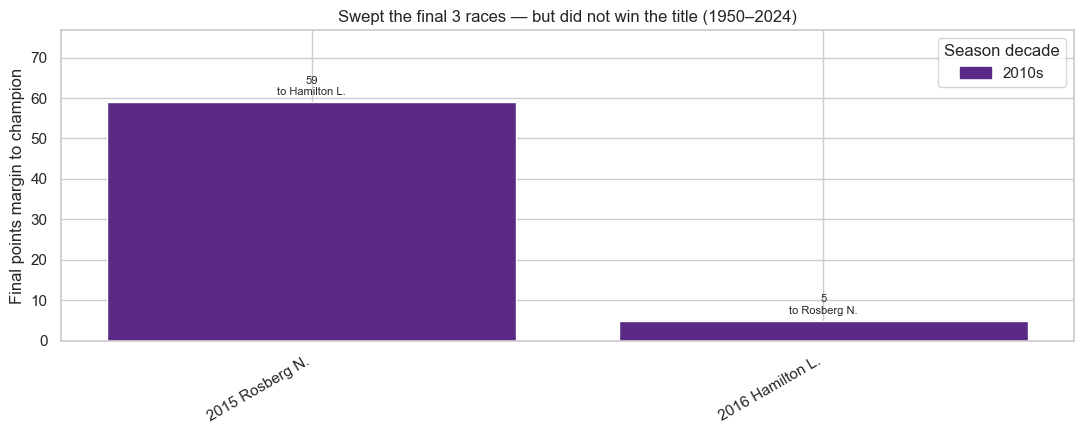

In [ ]:
# Step 1 — for each season, identify the FINAL 3 rounds
season_rounds = (
    races.groupby('year')['round'].max().reset_index()
    .rename(columns={'round': 'final_round'})
)
season_rounds = season_rounds[season_rounds['final_round'] >= 3]   # need at least 3 races
season_rounds['r_minus_2'] = season_rounds['final_round'] - 2
season_rounds['r_minus_1'] = season_rounds['final_round'] - 1

# Step 2 — race winners (positionOrder == 1) joined with the race's year + round
# Using 'positionOrder' is safer than 'position' (which can be a string for DNFs).
race_winners = (
    results.loc[results['positionOrder'] == 1, ['raceId', 'driverId']]
    .merge(races[['raceId', 'year', 'round', 'name']], on='raceId')
    .rename(columns={'name': 'gp'})
)

# Step 3 — flag races that are in the "last 3" of their season
final3 = race_winners.merge(season_rounds, on='year')
final3 = final3[final3['round'].between(final3['r_minus_2'], final3['final_round'])].copy()

# Step 4 — keep only (year, driver) groups that won ALL 3 of the final rounds
swept = (
    final3.groupby(['year', 'driverId'])
          .filter(lambda g: g['round'].nunique() == 3)
)

# Step 5 — drop the actual champions (we only want the ones who DIDN'T win the title)
champion_ids = set(zip(champions['year'], champions['driverId']))
swept = swept[~swept[['year', 'driverId']].apply(tuple, axis=1).isin(champion_ids)]

# Step 6 — collapse to one row per (year, driver) with the 3 GP names and the margin
if len(swept):
    summary = (
        swept.groupby(['year', 'driverId'])
        .agg(gps=('gp', lambda s: ', '.join(s)))
        .reset_index()
        .merge(drivers[['driverId', 'driver']], on='driverId')
        .merge(final_standings[['year', 'driverId', 'champ_points']]
               .rename(columns={'champ_points': 'final_points'}),
               on=['year', 'driverId'])
        .merge(champions[['year', 'driver', 'champ_points']]
               .rename(columns={'driver': 'champion', 'champ_points': 'champion_points'}),
               on='year')
    )
    summary['margin'] = summary['champion_points'] - summary['final_points']
    summary = summary[['year', 'driver', 'gps', 'final_points',
                       'champion', 'champion_points', 'margin']].sort_values('year')
else:
    summary = pd.DataFrame(columns=['year', 'driver', 'gps', 'final_points',
                                    'champion', 'champion_points', 'margin'])

print(f"Driver-seasons that swept the final 3 races but missed the title: {len(summary)}")
print()
print(summary.to_string(index=False))


# Bar chart — sorted by year, one bar per case, height = margin to the champion
if len(summary):
    plot_df = summary.copy()
    plot_df['decade'] = (plot_df['year'] // 10) * 10
    plot_df = plot_df.sort_values('year')

    plt.figure(figsize=(11, 4.5))
    bar_colors = [DECADE_COLORS[d] for d in plot_df['decade']]
    bars = plt.bar(plot_df['year'].astype(str) + ' ' + plot_df['driver'],
                   plot_df['margin'],
                   color=bar_colors, edgecolor='white')

    for bar, row in zip(bars, plot_df.itertuples()):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(plot_df['margin']) * 0.02,
                 f'{row.margin:.0f}\nto {row.champion}',
                 ha='center', va='bottom', fontsize=8)

    used = sorted(plot_df['decade'].unique())
    handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
               for d in used]
    plt.legend(handles=handles, title='Season decade', loc='upper right', frameon=True)

    plt.title('Swept the final 3 races — but did not win the title (1950–2024)')
    plt.ylabel('Final points margin to champion')
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0, plot_df['margin'].max() * 1.30)
    plt.tight_layout()
    show_and_save('3.2_swept_final3_no_title.png')
else:
    print('No such seasons in the dataset — nothing to plot.')


**SQL equivalent**
```sql
-- 3.2: Drivers who won ALL 3 of the final races of a season but were NOT
--       the eventual champion. (Indy excluded.)
WITH season_rounds AS (
    SELECT  ra.year, MAX(ra.round) AS final_round
    FROM    races ra
    WHERE   ra.name NOT LIKE '%Indianapolis%'
    GROUP   BY ra.year
    HAVING  MAX(ra.round) >= 3
),
last3_winners AS (
    SELECT  ra.year, ra.round, r.driverId
    FROM    results r
    JOIN    races   ra ON r.raceId = ra.raceId
    JOIN    season_rounds sr ON ra.year = sr.year
    WHERE   r.positionOrder = 1
      AND   ra.name NOT LIKE '%Indianapolis%'
      AND   ra.round BETWEEN sr.final_round - 2 AND sr.final_round
),
sweepers AS (
    SELECT  year, driverId
    FROM    last3_winners
    GROUP   BY year, driverId
    HAVING  COUNT(DISTINCT round) = 3              -- swept all three
),
champion AS (
    SELECT  s.year, s.driverId
    FROM    driver_standings s
    JOIN    races            ra ON s.raceId = ra.raceId
    JOIN    season_rounds    sr ON ra.year = sr.year AND ra.round = sr.final_round
    WHERE   s.position = 1
)
SELECT  sw.year,
        d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver
FROM    sweepers sw
LEFT    JOIN champion c ON sw.year = c.year AND sw.driverId = c.driverId
JOIN    drivers  d ON sw.driverId = d.driverId
WHERE   c.driverId IS NULL                          -- did NOT win the title
ORDER   BY sw.year;
```


---
### Chart 3.3 — Seasons where the champion did NOT finish the last race

The title is already won (or lost) before the chequered flag of the final round drops — but how often did the new champion's car not even reach the end of that race? Either the title was already mathematically clinched and the DNF was harmless, or the championship was so close that the DNF could have cost them the crown.

**Rule for "did not finish"**: the driver's `status` for the final race is **anything other than `Finished` or `+N Lap(s)`** — that covers DNFs (engine, accident, hydraulics, …), DNS (didn't start), and DSQ (disqualified). We also include the rare case where the champion was **absent from the entry list entirely** for the final race.

> **Note on the chart.** The question itself is yes/no ("did the champion DNF?"), so each qualifying season is just **one bar on the timeline**. The bar **height = title margin** (champion points − runner-up points) is added as *context only* — to show at a glance whether the DNF was harmless (tall bar, title long-clinched) or genuinely scary (short bar, came close to losing the championship). Read the chart as a timeline of events; the y-axis is supplemental colour, not the headline measurement.

**Output** — one row per (year, champion) with the final-round GP, the DNF status (or `Did not enter`), and the title margin.


Seasons where the champion did NOT finish the final race: 15 of 75 (20%)

 year        driver                       gp        status  title_margin
 1953     Ascari A.       Italian Grand Prix      Accident           6.5
 1961       Hill P. United States Grand Prix Did not enter           1.0
 1965      Clark J.       Mexican Grand Prix        Engine          14.0
 1970      Rindt J.       Mexican Grand Prix Did not enter           5.0
 1972 Fittipaldi E. United States Grand Prix    Suspension          16.0
 1973    Stewart J. United States Grand Prix      Withdrew          16.0
 1977      Lauda N.      Japanese Grand Prix Did not enter          17.0
 1979  Scheckter J. United States Grand Prix          Tyre           4.0
 1985      Prost A.    Australian Grand Prix        Engine          20.0
 1987     Piquet N.    Australian Grand Prix        Brakes          12.0
 1989      Prost A.    Australian Grand Prix      Withdrew          16.0
 1990      Senna A.    Australian Grand Prix      

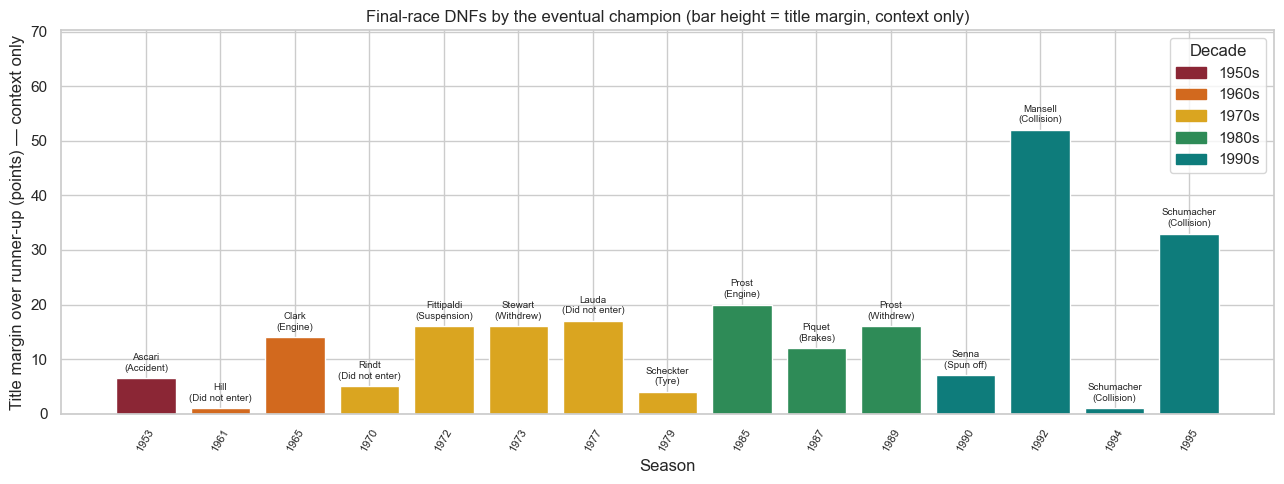

In [ ]:
# Step 1 — load status table for human-readable DNF reasons
status = pd.read_csv('excel/status.csv')

# A status is a "finish" only if it equals 'Finished' or matches '+N Lap(s)'.
# Everything else (Engine, Accident, Disqualified, Did not start, ...) is a DNF.
is_finish = status['status'].str.match(r'^(Finished|\+\d+ Laps?)$', na=False)
finished_status_ids = set(status.loc[is_finish, 'statusId'])


# Step 2 — for each season's FINAL race, pull the CHAMPION's result
final_race_results = (
    last_race_per_year[['year', 'final_raceId']]
    .merge(champions[['year', 'driverId', 'driver']], on='year')
    .merge(results[['raceId', 'driverId', 'statusId', 'positionOrder']]
           .rename(columns={'raceId': 'final_raceId'}),
           on=['final_raceId', 'driverId'],
           how='left')
    .merge(races[['raceId', 'name']].rename(columns={'raceId': 'final_raceId',
                                                     'name': 'gp'}),
           on='final_raceId')
    .merge(status, on='statusId', how='left')
)

# 'status' is NaN when the champion didn't appear in 'results' for the final race
# at all — treat that as "Did not enter".
final_race_results['status'] = final_race_results['status'].fillna('Did not enter')

# Step 3 — keep only the seasons where the status is NOT in the "finish" set
final_race_results['finished'] = final_race_results['statusId'].isin(finished_status_ids)
champ_dnf = final_race_results[~final_race_results['finished']].copy()


# Step 4 — add title margin (champion points − runner-up points) as CONTEXT for the chart.
# The chart's headline answer is yes/no ("did the champion DNF?"); margin only tells us
# whether the DNF was safe (huge margin) or scary (tiny margin).
runner_up_final = (
    final_standings.query('champ_position == 2')
    [['year', 'champ_points']]
    .rename(columns={'champ_points': 'runner_up_points'})
)
champ_dnf = (
    champ_dnf
    .merge(champions[['year', 'champ_points']], on='year')
    .merge(runner_up_final, on='year', how='left')
)
champ_dnf['title_margin'] = champ_dnf['champ_points'] - champ_dnf['runner_up_points']

out = (champ_dnf[['year', 'driver', 'gp', 'status', 'title_margin']]
       .sort_values('year'))

print(f"Seasons where the champion did NOT finish the final race: "
      f"{len(out)} of {len(champions)} ({len(out) / len(champions):.0%})")
print()
print(out.to_string(index=False))


# Bar chart — one bar per qualifying season. The chart is essentially a TIMELINE of
# which seasons had this event. Bar HEIGHT = title margin is shown only as context:
# tall bar = title long-clinched, short bar = DNF nearly cost the championship.
if len(out):
    plot_df = champ_dnf.copy()
    plot_df['decade'] = (plot_df['year'] // 10) * 10
    plot_df = plot_df.sort_values('year')

    fig, ax = plt.subplots(figsize=(13, 5))
    bar_colors = [DECADE_COLORS[d] for d in plot_df['decade']]
    bars = ax.bar(plot_df['year'].astype(str),
                  plot_df['title_margin'],
                  color=bar_colors, edgecolor='white')

    for bar, row in zip(bars, plot_df.itertuples()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + plot_df['title_margin'].max() * 0.02,
                f'{row.driver.split()[0]}\n({row.status})',
                ha='center', va='bottom', fontsize=7)

    ax.set_title("Final-race DNFs by the eventual champion "
                 "(bar height = title margin, context only)")
    ax.set_xlabel('Season')
    ax.set_ylabel('Title margin over runner-up (points) — context only')
    ax.tick_params(axis='x', labelrotation=60, labelsize=8)
    ax.set_ylim(0, plot_df['title_margin'].max() * 1.35)

    used = sorted(plot_df['decade'].unique())
    handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
               for d in used]
    plt.legend(handles=handles, title='Decade', loc='upper right', frameon=True)

    plt.tight_layout()
    show_and_save('3.3_champion_dnf_finale.png')
else:
    print('No champion ever DNFed the last race in this dataset — nothing to plot.')


**SQL equivalent**
```sql
-- 3.3: Seasons where the eventual champion did NOT finish the final race.
--      Indy races excluded; "finished" = status is 'Finished' or '+N Lap(s)'.
WITH season_rounds AS (
    SELECT  ra.year, MAX(ra.round) AS final_round
    FROM    races ra
    WHERE   ra.name NOT LIKE '%Indianapolis%'
    GROUP   BY ra.year
),
final_race AS (
    SELECT  ra.raceId, ra.year, ra.name AS gp
    FROM    races ra
    JOIN    season_rounds sr ON ra.year = sr.year AND ra.round = sr.final_round
    WHERE   ra.name NOT LIKE '%Indianapolis%'
),
champion AS (
    SELECT  fr.year, s.driverId
    FROM    driver_standings s
    JOIN    final_race fr ON s.raceId = fr.raceId
    WHERE   s.position = 1
)
SELECT
    fr.year,
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.'  AS champion,
    fr.gp                                                AS final_gp,
    COALESCE(st.status, 'Did not enter')                 AS finale_status
FROM   champion   c
JOIN   final_race fr ON c.year = fr.year
JOIN   drivers    d  ON c.driverId = d.driverId
LEFT   JOIN results r  ON r.raceId = fr.raceId AND r.driverId = c.driverId
LEFT   JOIN status  st ON r.statusId = st.statusId
WHERE  st.status IS NULL                                       -- did not enter
   OR  (st.status <> 'Finished' AND st.status NOT LIKE '+% Lap%')
ORDER  BY fr.year;
```


---
## Key insights from this notebook

After running the three storyline questions:

1. **Wire-to-wire seasons are very rare.** Only a handful of drivers have ever led the standings after *every* round of a season. Even dominant title runs usually have one race where someone else briefly went top of the table (an early-season chaos race or a DNF).

2. **Winning the final 3 races and *still* losing the title is essentially impossible.** Three consecutive wins to close a season is already a 75-point swing in the modern era — a driver capable of doing that is almost always going to be ahead on points anyway. This filter exposes the extreme outliers: cases where one driver dominated the back half of the year but had already lost the title because of an early-season collapse.

3. **Champions DNFing the final race is more common than you'd guess.** Because the title is usually clinched before the last round, the eventual champion can afford to retire from the final race with no consequence. The bar height (title margin) tells you whether the DNF was genuinely irrelevant (huge margin) or a near-disaster (margin of 1–3 points).
